## Imports & Global Settings

In [1]:
import numpy as np
import pandas as pd
import random
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns
import shap

np.random.seed(42)
random.seed(42)

## Dataset Selection & Loading

In [2]:
DATASET_NAME = "cicids2018"

DATASET_PATHS = {
    "cicids2017": "cicids2017.csv",
    "cicids2018": "cicids2018.csv",
    "cicddos2019": "cicddos2019.csv"
}

df = pd.read_csv(DATASET_PATHS[DATASET_NAME])
print("Dataset:", DATASET_NAME)
print("Shape:", df.shape)
df.head()

Dataset: cicids2018
Shape: (50000, 80)


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,44576,6,16/02/2018 01:47:52,4101544,5,3,935,411,935,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,80,6,16/02/2018 01:48:30,44580,2,0,0,0,0,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-Hulk
2,80,6,16/02/2018 01:48:24,68481,3,0,0,0,0,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-Hulk
3,80,6,16/02/2018 01:47:57,43025,2,0,0,0,0,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-Hulk
4,80,6,16/02/2018 01:47:30,8244,2,0,0,0,0,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,DoS attacks-Hulk


## Data Cleaning & Preprocessing

In [3]:
# 1. Remove duplicate rows
df = df.drop_duplicates()

# 2. Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 3. Drop rows with missing values
df.dropna(inplace=True)

# 4. Identify label column (usually 'Label' in CIC datasets)
label_col = 'Label' if 'Label' in df.columns else df.columns[-1]

# 5. Encode labels (Benign = 0, Attack = 1 or multiclass → numeric)
le = LabelEncoder()
df[label_col] = le.fit_transform(df[label_col])

# 6. Split features and target
X = df.drop(columns=[label_col])
y = df[label_col]

# 7. Drop non-numeric columns (e.g., Timestamp)
non_numeric_cols = X.select_dtypes(include=['object']).columns
if len(non_numeric_cols) > 0:
    print("Dropping non-numeric columns:", list(non_numeric_cols))
    X = X.drop(columns=non_numeric_cols)

# 8. Final sanity check
assert X.dtypes.apply(lambda x: np.issubdtype(x, np.number)).all(), \
    "Non-numeric features still present!"

print("Final feature count:", X.shape[1])
print("Class distribution:\n", y.value_counts())

Dropping non-numeric columns: ['Timestamp']
Final feature count: 78
Class distribution:
 Label
1    21980
0    21226
2     4588
Name: count, dtype: int64


## Train-Test Split (70/30)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(33455, 78) (14339, 78)


## Normalization

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Handle Class Imbalance using SMOTE (train only)

In [6]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE class distribution:", np.bincount(y_train_bal))

After SMOTE class distribution: [15386 15386 15386]


## Feature Selection using PCA

In [7]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_bal)
X_test_pca = pca.transform(X_test_scaled)

print("PCA components:", X_train_pca.shape[1])

PCA components: 9


## Model Definition

In [8]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

## Train Models & Predict

In [9]:
results = {}
probas = {}

for name, model in models.items():
    model.fit(X_train_pca, y_train_bal)
    y_pred = model.predict(X_test_pca)
    y_prob = model.predict_proba(X_test_pca)[:, 1] if hasattr(model, "predict_proba") else None

    results[name] = {
      "Accuracy": accuracy_score(y_test, y_pred),
      "Precision": precision_score(y_test, y_pred, average='weighted'),
      "Recall": recall_score(y_test, y_pred, average='weighted'),
      "F1": f1_score(y_test, y_pred, average='weighted'),
      "Confusion": confusion_matrix(y_test, y_pred)
    }

    probas[name] = y_prob

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,Confusion
Random Forest,0.999791,0.999791,0.999791,0.999791,"[[6366, 2, 0], [1, 6593, 0], [0, 0, 1377]]"
Logistic Regression,0.995048,0.995069,0.995048,0.995048,"[[6310, 58, 0], [13, 6581, 0], [0, 0, 1377]]"
KNN,0.99993,0.99993,0.99993,0.99993,"[[6368, 0, 0], [1, 6593, 0], [0, 0, 1377]]"
SVM,0.998187,0.998191,0.998187,0.998187,"[[6345, 23, 0], [3, 6591, 0], [0, 0, 1377]]"
Decision Tree,0.999582,0.999582,0.999582,0.999582,"[[6364, 4, 0], [2, 6592, 0], [0, 0, 1377]]"


## Decision Tree Feature Importance

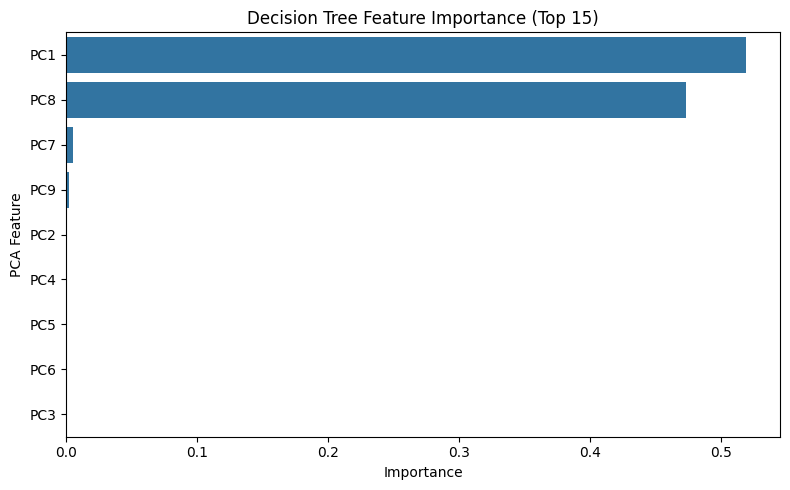

In [10]:
pca_feature_names = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]

dt_model = models.get("Decision Tree")
if hasattr(dt_model, "feature_importances_"):
    importances = pd.Series(dt_model.feature_importances_, index=pca_feature_names)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.head(15).values, y=importances.head(15).index)
    plt.title("Decision Tree Feature Importance (Top 15)")
    plt.xlabel("Importance")
    plt.ylabel("PCA Feature")
    plt.tight_layout()
    plt.show()
else:
    print("Decision Tree model is not fitted or has no feature_importances_.")

## SHAP Explanations (Other Models)

SHAP for Random Forest


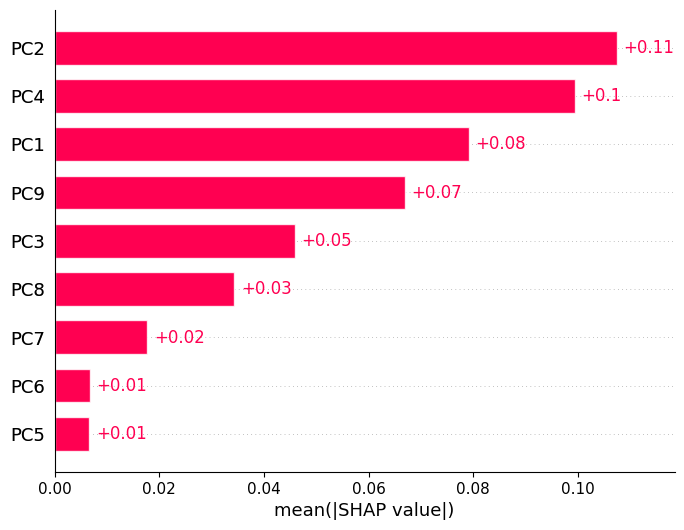

SHAP for Logistic Regression


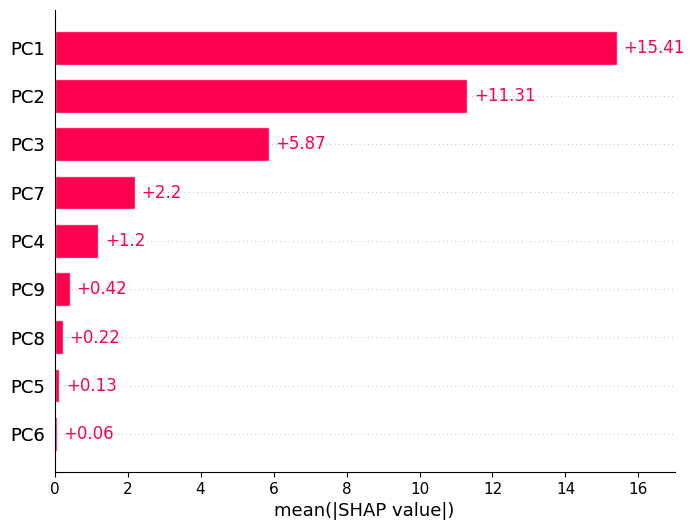

SHAP for KNN
SHAP failed for KNN: The passed model is not callable and cannot be analyzed directly with the given masker! Model: KNeighborsClassifier()
SHAP for SVM
SHAP failed for SVM: The passed model is not callable and cannot be analyzed directly with the given masker! Model: SVC(probability=True, random_state=42)


In [11]:
shap_sample = shap.utils.sample(X_train_pca, 200, random_state=42)

for name, model in models.items():
    if name == "Decision Tree":
        continue
    print(f"SHAP for {name}")
    try:
        explainer = shap.Explainer(model, shap_sample, feature_names=pca_feature_names)
        shap_values = explainer(shap_sample)

        if isinstance(shap_values, list):
            values_to_plot = shap_values[0]
            if len(shap_values) > 1:
                values_to_plot = shap_values[1]
        else:
            if getattr(shap_values, "values", None) is not None and shap_values.values.ndim == 3:
                values_to_plot = shap_values[:, :, 1]
            else:
                values_to_plot = shap_values

        shap.plots.bar(values_to_plot, max_display=15, show=True)
    except Exception as e:
        print(f"SHAP failed for {name}: {e}")

## Confusion Matrices

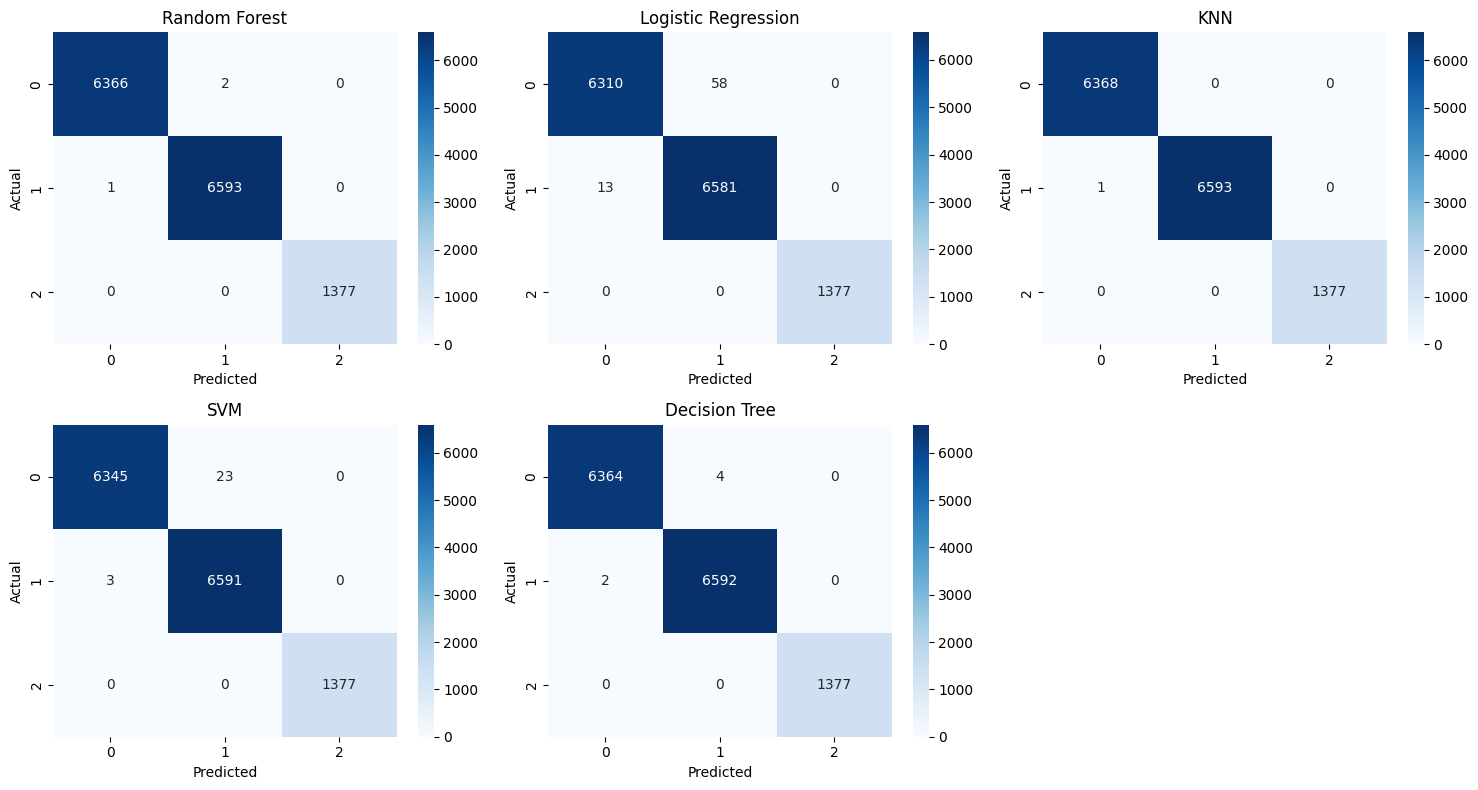

In [12]:
plt.figure(figsize=(15,8))
for i, (name, res) in enumerate(results.items(), 1):
    plt.subplot(2, 3, i)
    sns.heatmap(res["Confusion"], annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Precision-Recall Curves

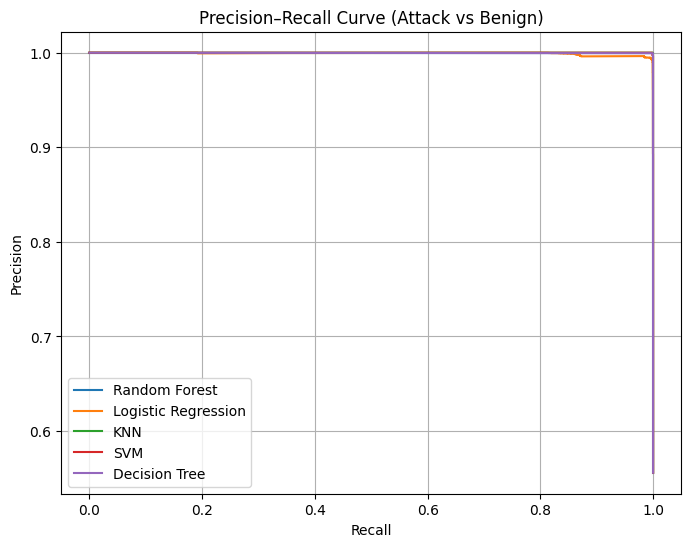

In [13]:
plt.figure(figsize=(8,6))

# Treat all non-zero classes as "Attack"
y_test_binary = (y_test != 0).astype(int)

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_pca)

        # Use max probability among attack classes
        attack_prob = y_prob[:, 1:].max(axis=1)

        precision, recall, _ = precision_recall_curve(y_test_binary, attack_prob)
        plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Attack vs Benign)")
plt.legend()
plt.grid()
plt.show()

## Accuracy Comparison

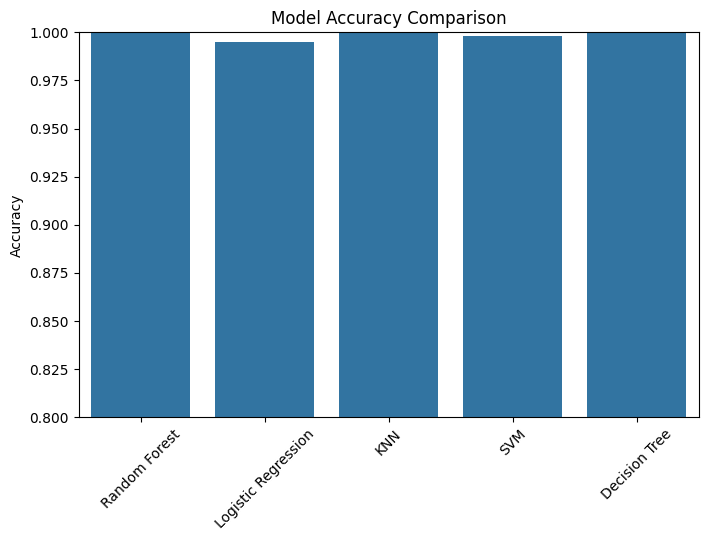

In [14]:
accs = {name: res["Accuracy"] for name, res in results.items()}
plt.figure(figsize=(8,5))
sns.barplot(x=list(accs.keys()), y=list(accs.values()))
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0.8,1.0)
plt.show()